In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
weather_path = Path("data/weather/all_weather_by_hour_2023-2025_v1.csv")
weather_raw = pd.read_csv(weather_path)
weather = weather_raw.copy()

In [3]:
weather['day_datetime'] = pd.to_datetime(weather['day_datetime'])
weather['hour_datetime'] = pd.to_datetime(weather['hour_datetime'])
weather['real_hour_datetime'] = pd.to_datetime(
    weather['day_datetime'].dt.date.astype(str) + ' ' + weather['hour_datetime'].dt.time.astype(str)
)
weather['city_clean'] = weather['city_address'].astype(str).apply(lambda x: x.split(',')[0].strip())

weather = weather[(weather['hour_temp'] >= -40) & (weather['hour_temp'] <= 50)]
weather['hour_conditions'] = weather['hour_conditions'].fillna('Unknown')
weather['month'] = weather['day_datetime'].dt.month


C:\Users\dimas\AppData\Local\Temp\ipykernel_15288\3755422939.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weather['hour_datetime'] = pd.to_datetime(weather['hour_datetime'])


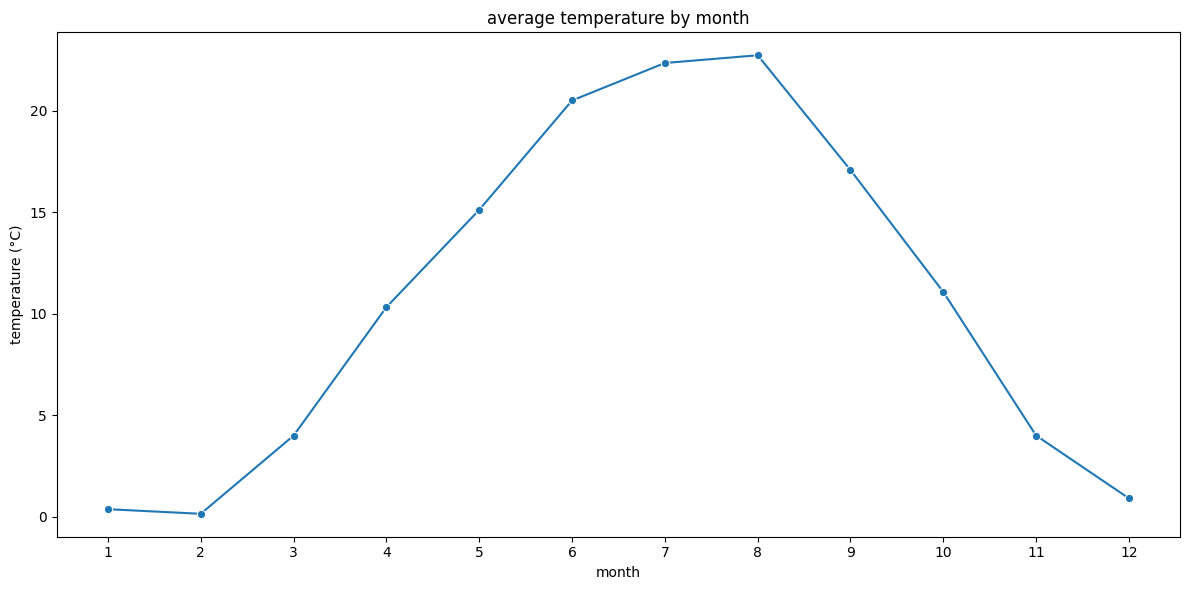

In [ ]:
plt.figure(figsize=(12, 6))
monthly_temp = weather.groupby('month')['hour_temp'].mean()

sns.lineplot(x=monthly_temp.index, y=monthly_temp.values, marker='o')
plt.title('average temperature by month')
plt.xlabel('month')
plt.ylabel('temperature (°C)')
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

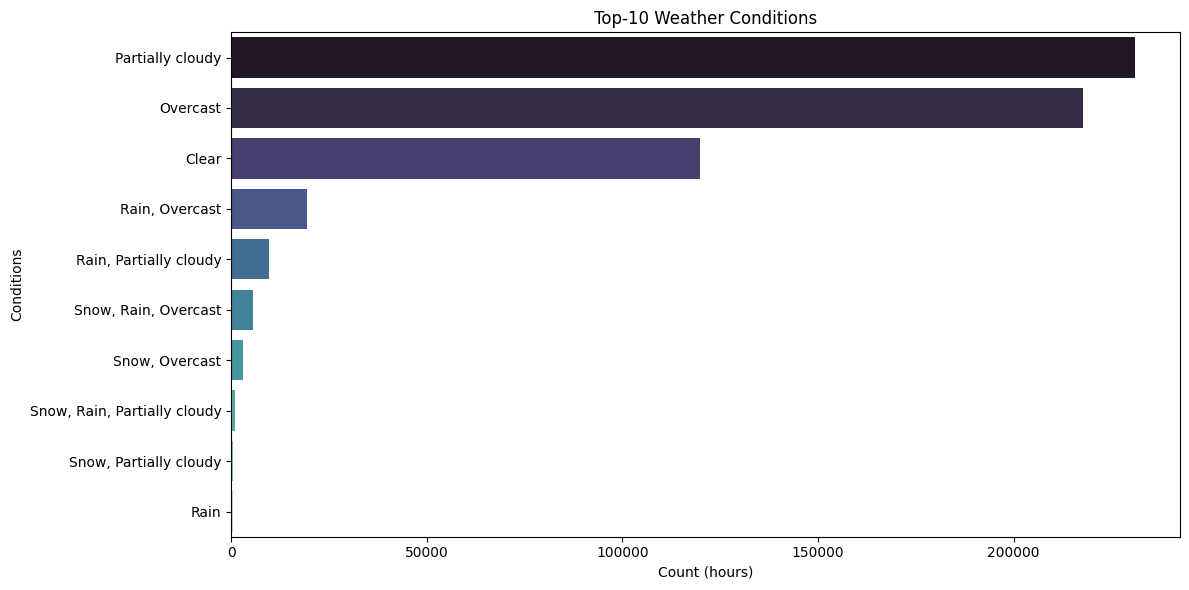

In [ ]:
plt.figure(figsize=(12, 6))
top_conditions = weather['hour_conditions'].value_counts().head(10)
sns.barplot(x=top_conditions.values, y=top_conditions.index, palette='mako')
plt.title('Top-10 Weather Conditions')
plt.xlabel('Count (hours)')
plt.ylabel('Conditions')
plt.tight_layout()
plt.show()

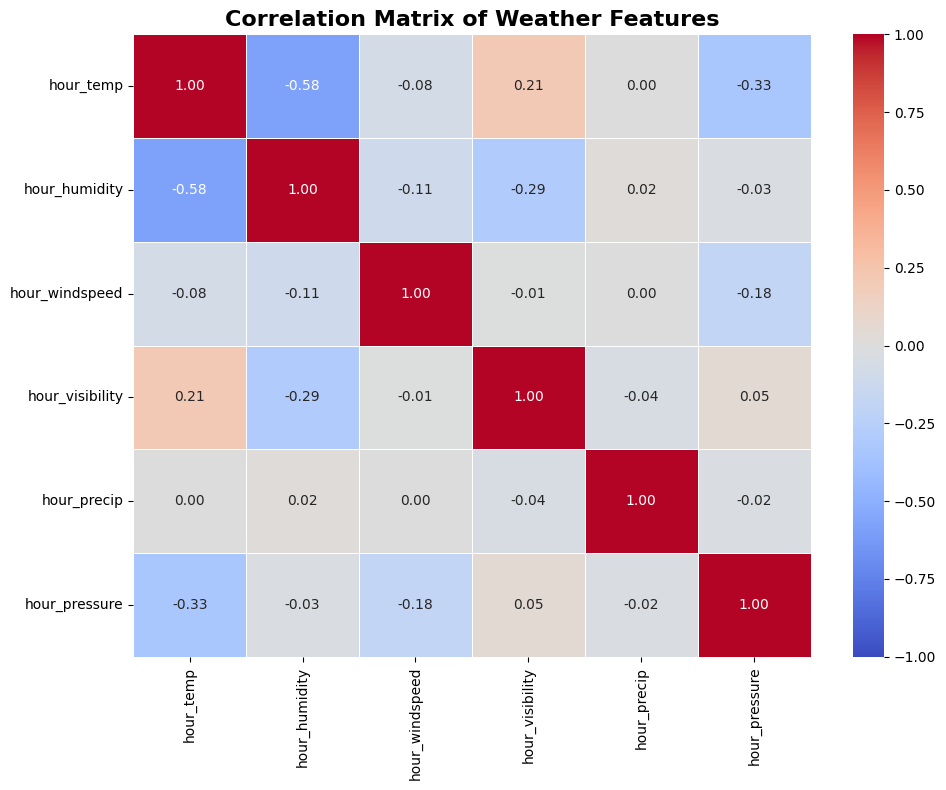

In [6]:
plt.figure(figsize=(10, 8))
weather_numeric = weather[['hour_temp', 'hour_humidity', 'hour_windspeed', 'hour_visibility', 'hour_precip', 'hour_pressure']]
corr_matrix = weather_numeric.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix of Weather Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()